## 1. Sampling And Sampling Rate
* By nature, a sound wave is a *continuous signal*, meaning it contains an infinite number of signal values in a given time.
* To be processed, stored, and transmitted by digital devices, the continuous sound wave needs to be converted into a series of discrete values, known as a *digital representation*.

### 1.1 Sampling
* **Sampling** is the process of measuring the value of a continuous signal at fixed time steps.
* The sampled waveform is discrete, since it contains a finite number of signal values at uniform intervals.
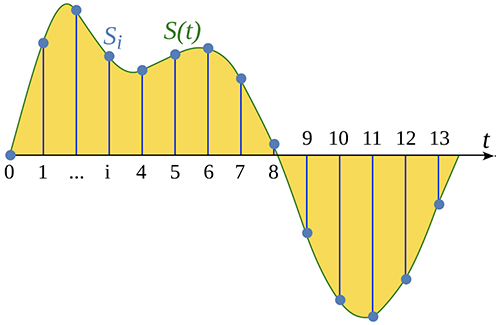

### 1.2 Sampling Rate
* It is the number of samples taken in one second and is measured in hertz (Hz).
* e.g. CD-quality audio has a sampling rate of 44,100 Hz, meaning samples are taken 44,100 times per second.
* Nyquist Limit
  * The maximum frequency that can be accurately captured when digitising a signal.
  * **Rule**: Sampling rate must be at least 2× the highest frequency in the signal.
  > f_nyquist = f_sample / 2
  * The audible frequencies in human speech are below 8 kHz and therefore sampling speech at 16 kHz is sufficient.
* **IMPORTANT**: If you plan to use custom audio data to fine-tune a pre-trained model, the sampling rate of your data should match the sampling rate of the data the model was pre-trained on.
* **Resampling** is the process of making the sampling rates match


## 2. Amplitude And Bit Depth

### 2.1 Amplitude
* The **amplitude** of a sound describes the sound pressure level at any given instant and is measured in decibels (dB).
* We perceive the amplitude as loudness.
### 2.2 Bit Depth
* The **bit depth** of the sample determines with how much precision this amplitude value can be described.
* The higher the bit depth, the more faithfully the digital representation approximates the original continuous sound wave.
  * The most common audio bit depths are 16-bit and 24-bit.
  * It represents the number of possible steps to which the amplitude value can be quantized when it’s converted from continuous to discrete: 65,536 steps for 16-bit audio, a whopping 16,777,216 steps for 24-bit audio.
* Since machine learning models naturally work on floating-point data, the audio must first be converted into floating-point format before it can be used to train the model.

## 3. Audio As A Waveform

In [7]:
# Python library librosa can be used for speech signal processing
!pip install librosa

total seconds of audio: 5.33


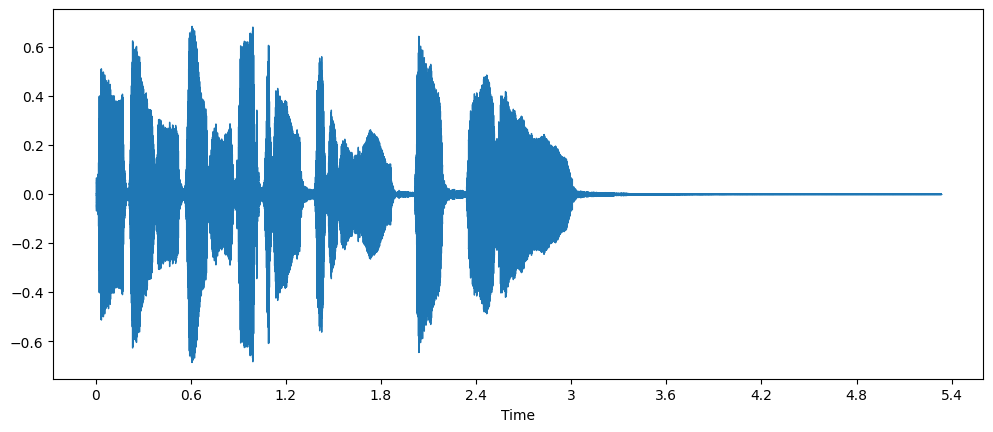

In [8]:
# Take an example sound called “trumpet” that comes with the library
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio

array, sampling_rate = librosa.load(librosa.ex('trumpet'))
# is a 1D NumPy array representing the audio waveform
# specifically, the amplitude of the sound signal sampled over time.

duration = len(array) / sampling_rate
print(f"total seconds of audio: {round(duration, 2)}")

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

Audio(data=array, rate=sampling_rate)

## 4. The Frequency Spectrum
* Frequency domain representation
  * The spectrum is computed using the discrete Fourier transform or DFT.
  * It describes the individual frequencies that make up the signal and how strong they are.

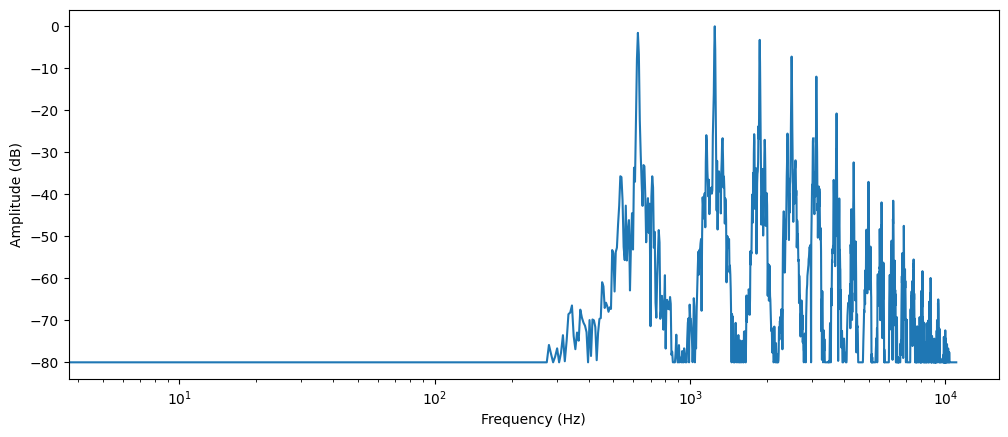

In [9]:
import numpy as np

# Only take the first 4096 samples
# which is roughly the length of the first note being played:
dft_input = array[:4096]

# calculate the DFT
window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)

# get the amplitude spectrum in decibels
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

# get the frequency bins
frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")

* This plots the strength of the various frequency components that are present in this audio segment.
* The waveform plots the amplitude of the audio signal over time, the spectrum visualizes the amplitudes of the individual frequencies at a fixed point in time.

## 5. Spectrogram
* The problem of the spectrum is that it only shows a frozen snapshot of the frequencies at a given instant.
* The solution is to take multiple DFTs, each covering only a small slice of time, and stack the resulting spectra together into a **spectrogram**.
* A spectrogram plots the frequency content of an audio signal as it changes over time.
* It allows you to see time, frequency, and amplitude all on one graph.
* The algorithm that performs this computation is the STFT or **Short Time Fourier Transform**.

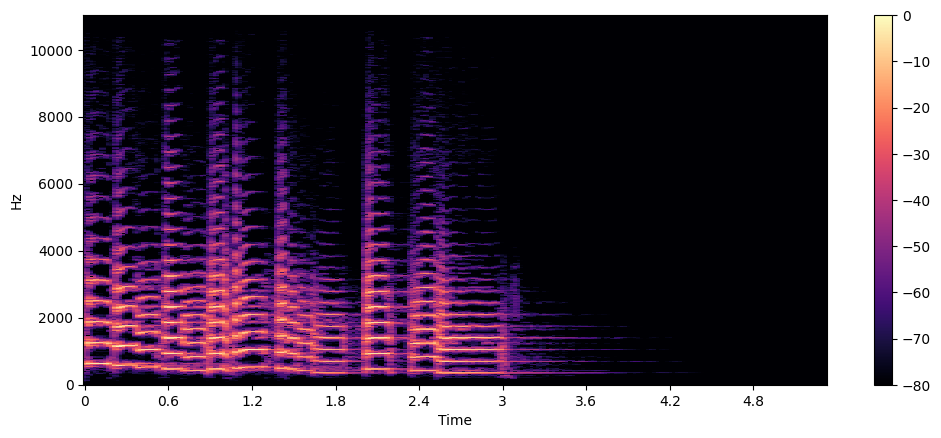

In [10]:
import numpy as np

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()

* The x-axis represents time as in the waveform visualization
* The y-axis represents frequency in Hz
* The intensity of the color gives the amplitude or power of the frequency component at each point in time, measured in decibels (dB).

## 6. Mel Spectrogram
* Human auditory system is more sensitive to changes in lower frequencies than higher frequencies, and this sensitivity decreases logarithmically as frequency increases.
* The mel scale is a perceptual scale that approximates the non-linear frequency response of the human ear.
* A Mel Spectrogram is a spectrogram where the frequency axis is converted from linear Hz to the mel scale, resulting in a time-frequency representation that better reflects how humans perceive sound.

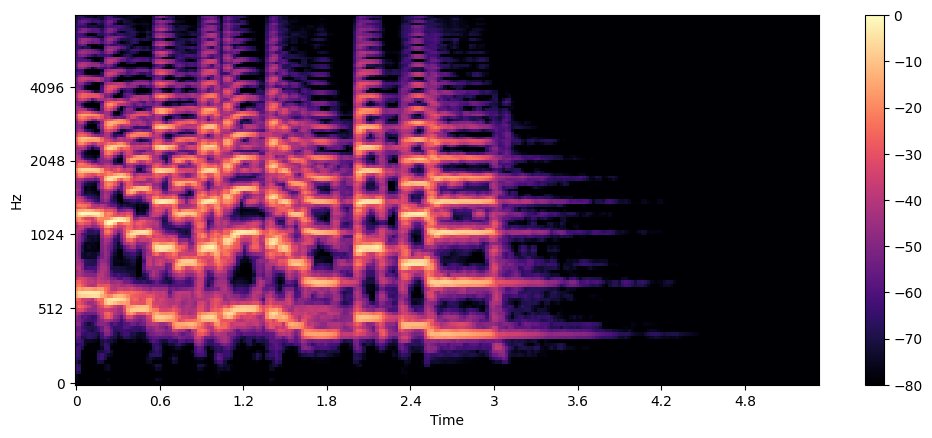

In [11]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()